# Step 3b — Gene Attention + Domain Alignment (Improved)

**Why v1 got target F1=0.079:**
| Problem | Fix |
|---|---|
| No domain alignment — raw target fed directly | **CORAL pre-alignment** (same as DANN) |
| Attention too sharp — softmax memorises source genes | **Temperature softmax (T=2)** → softer weights |
| Attention acts as filter, not refinement | **Residual connection** `x_att + x` |
| No transfer signal during training | **MMD loss** between source/target latent embeddings |

```
Input x (3000)
  ├──► Attention MLP: Dense(256)→ReLU→Dense(3000)→Softmax(T=2) → w
  ├──► x_att  = x * w * n_genes
  ├──► x_res  = x_att + x            ← residual keeps full-spectrum info
  └──► Dense(512)→LN→Drop(0.4)→Dense(256)→LN→Drop(0.3)→Dense(128) = z
            │
            ├── CE loss  (source, class-weighted)
            └── MMD loss (source z vs target z, λ=0.5)
```

In [1]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'step3_self_attention' else Path.cwd()
RESULTS_DIR  = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('TF:', tf.__version__)

Project root: /Users/kirtan/Projects /NNDL
TF: 2.21.0


## 1. Data + CORAL Alignment

In [2]:
X_train = np.load(PROJECT_ROOT / 'step3_X_train.npy').astype(np.float32)
y_train = np.load(PROJECT_ROOT / 'step3_y_train.npy').astype(np.int64)
X_test  = np.load(PROJECT_ROOT / 'step3_X_test.npy').astype(np.float32)
y_test  = np.load(PROJECT_ROOT / 'step3_y_test.npy').astype(np.int64)

with open(PROJECT_ROOT / 'step3_label_mapping.json') as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in range(len(label_map))]
n_classes   = len(class_names)
n_genes     = X_train.shape[1]

X_target_raw = np.load(PROJECT_ROOT / 'gse126030_preprocessed.npy').astype(np.float32)
df_labels    = pd.read_csv(PROJECT_ROOT / 'improvements/1_label_validation/label_validation_output/gse126030_reclustered_labels.csv')
mask         = (df_labels['confidence'] >= 0.55) & (df_labels['new_class'] != 'Uncertain')
y_target_eval = np.array([class_names.index(n) for n in df_labels.loc[mask, 'new_class']], dtype=np.int64)

classes, counts = np.unique(y_train, return_counts=True)
class_weight = {int(c): len(y_train) / (n_classes * cnt) for c, cnt in zip(classes, counts)}
print(f'Train: {X_train.shape}  n_genes: {n_genes}  Classes: {class_names}')

Train: (6824, 3000)  n_genes: 3000  Classes: ['Effector', 'Exhausted', 'Naive', 'Other_CD4', 'Th1-like', 'Treg']


In [3]:
def coral_align(X_src, X_tgt, reg=1e-3):
    src_mean = X_src.mean(axis=0)
    Xs = X_src - src_mean
    Xt = X_tgt - X_tgt.mean(axis=0)
    Cs = (Xs.T @ Xs) / (Xs.shape[0] - 1) + reg * np.eye(Xs.shape[1])
    Ct = (Xt.T @ Xt) / (Xt.shape[0] - 1) + reg * np.eye(Xt.shape[1])

    def mat_sqrt(M):
        v, V = np.linalg.eigh(M)
        return V @ np.diag(np.sqrt(np.maximum(v, 0))) @ V.T

    def mat_inv_sqrt(M):
        v, V = np.linalg.eigh(M)
        return V @ np.diag(1.0 / np.sqrt(np.maximum(v, 1e-10))) @ V.T

    W = mat_inv_sqrt(Ct) @ mat_sqrt(Cs)
    return ((Xt @ W) + src_mean).astype(np.float32)

print('Running CORAL alignment...')
X_target_coral = coral_align(X_train, X_target_raw)
X_target_eval  = X_target_coral[mask.values]
X_target_train = X_target_coral          # unlabeled, for MMD
print(f'CORAL done. Target eval: {X_target_eval.shape}')

Running CORAL alignment...
CORAL done. Target eval: (12776, 3000)


## 2. MMD Loss + Model

In [4]:
@tf.function
def compute_mmd(x, y, sigmas=(1.0, 5.0, 10.0, 20.0)):
    """Multi-scale RBF kernel MMD between batches x and y."""
    def rbf_kernel(a, b):
        a_norm = tf.reduce_sum(tf.square(a), axis=1, keepdims=True)
        b_norm = tf.reduce_sum(tf.square(b), axis=1, keepdims=True)
        dist   = a_norm - 2.0 * tf.matmul(a, b, transpose_b=True) + tf.transpose(b_norm)
        dist   = tf.maximum(dist, 0.0)
        k = tf.zeros_like(dist)
        for s in sigmas:
            k += tf.exp(-dist / (2.0 * s ** 2))
        return k

    kxx = rbf_kernel(x, x)
    kyy = rbf_kernel(y, y)
    kxy = rbf_kernel(x, y)
    return tf.reduce_mean(kxx) + tf.reduce_mean(kyy) - 2.0 * tf.reduce_mean(kxy)

print('MMD function ready.')

MMD function ready.


In [5]:
class GeneAttentionMMD(keras.Model):
    def __init__(self, n_genes, n_classes, attention_temp=2.0, mmd_weight=0.5, **kwargs):
        super().__init__(**kwargs)
        self.n_genes       = n_genes
        self.mmd_weight    = mmd_weight
        self.att_temp      = attention_temp

        # Attention MLP
        self.att_hidden = layers.Dense(256, activation='relu', name='att_hidden')
        self.att_drop   = layers.Dropout(0.3)
        self.att_logits = layers.Dense(n_genes, name='att_logits')   # no activation — we apply temp softmax manually

        # Classifier
        self.dense1  = layers.Dense(512, activation='relu')
        self.ln1     = layers.LayerNormalization()
        self.drop1   = layers.Dropout(0.4)
        self.dense2  = layers.Dense(256, activation='relu')
        self.ln2     = layers.LayerNormalization()
        self.drop2   = layers.Dropout(0.3)
        self.dense3  = layers.Dense(128, activation='relu', name='latent')
        self.drop3   = layers.Dropout(0.2)
        self.output_layer = layers.Dense(n_classes, activation='softmax')

        # Metrics
        self.loss_tracker     = keras.metrics.Mean(name='loss')
        self.ce_loss_tracker  = keras.metrics.Mean(name='ce_loss')
        self.mmd_loss_tracker = keras.metrics.Mean(name='mmd_loss')
        self.acc_tracker      = keras.metrics.SparseCategoricalAccuracy(name='accuracy')

    def encode(self, x, training=False):
        # Attention branch — temperature-scaled softmax
        h   = self.att_hidden(x)
        h   = self.att_drop(h, training=training)
        logits = self.att_logits(h)
        w   = tf.nn.softmax(logits / self.att_temp, axis=-1)  # softer with T>1

        # Attended + residual
        x_att = x * w * self.n_genes   # scale to preserve magnitude
        x_res = x_att + x              # residual: attention refines, doesn't filter

        # Classifier trunk
        z = self.dense1(x_res)
        z = self.ln1(z)
        z = self.drop1(z, training=training)
        z = self.dense2(z)
        z = self.ln2(z)
        z = self.drop2(z, training=training)
        z = self.dense3(z)
        z = self.drop3(z, training=training)
        return z, w

    def call(self, x, training=False):
        z, _ = self.encode(x, training=training)
        return self.output_layer(z)

    def train_step(self, data):
        (src_x, src_y), (tgt_x,) = data

        with tf.GradientTape() as tape:
            z_src, _ = self.encode(src_x, training=True)
            z_tgt, _ = self.encode(tgt_x, training=True)

            y_pred   = self.output_layer(z_src)
            ce_loss  = tf.reduce_mean(
                keras.losses.sparse_categorical_crossentropy(src_y, y_pred)
            )
            mmd_loss = compute_mmd(z_src, z_tgt)
            total    = ce_loss + self.mmd_weight * mmd_loss

        grads = tape.gradient(total, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(total)
        self.ce_loss_tracker.update_state(ce_loss)
        self.mmd_loss_tracker.update_state(mmd_loss)
        self.acc_tracker.update_state(src_y, y_pred)
        return {
            'loss':     self.loss_tracker.result(),
            'ce_loss':  self.ce_loss_tracker.result(),
            'mmd_loss': self.mmd_loss_tracker.result(),
            'accuracy': self.acc_tracker.result(),
        }

    def test_step(self, data):
        x, y = data
        y_pred = self(x, training=False)
        loss = tf.reduce_mean(keras.losses.sparse_categorical_crossentropy(y, y_pred))
        self.ce_loss_tracker.update_state(loss)
        self.acc_tracker.update_state(y, y_pred)
        return {'ce_loss': self.ce_loss_tracker.result(), 'accuracy': self.acc_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker, self.ce_loss_tracker, self.mmd_loss_tracker, self.acc_tracker]

print('GeneAttentionMMD defined.')

GeneAttentionMMD defined.


## 3. Datasets + Training

In [6]:
BATCH_SIZE    = 128
LEARNING_RATE = 2e-4
MMD_WEIGHT    = 0.5
ATT_TEMP      = 2.0
MAX_EPOCHS    = 100
PATIENCE      = 15

model = GeneAttentionMMD(
    n_genes=n_genes,
    n_classes=n_classes,
    attention_temp=ATT_TEMP,
    mmd_weight=MMD_WEIGHT,
    name='GeneAttentionMMD'
)
model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE, clipnorm=1.0))

# Zip source (labeled) + target (unlabeled CORAL-aligned)
src_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(10000, seed=42)
    .batch(BATCH_SIZE, drop_remainder=True)
)
tgt_ds = (
    tf.data.Dataset.from_tensor_slices((X_target_train,))
    .shuffle(100000, seed=42)
    .batch(BATCH_SIZE, drop_remainder=True)
    .repeat()
)
train_ds = tf.data.Dataset.zip((src_ds, tgt_ds))
val_ds   = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_ce_loss', mode='min',
        patience=PATIENCE, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_ce_loss', mode='min',
        factor=0.5, patience=7, min_lr=1e-6, verbose=1
    ),
]

print(f'Steps/epoch: {len(src_ds)}')

Steps/epoch: 53


In [7]:
history = model.fit(
    train_ds,
    epochs=MAX_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.4362 - ce_loss: 1.5595 - loss: 1.5824 - mmd_loss: 0.0457 - val_accuracy: 0.7245 - val_ce_loss: 0.7386 - learning_rate: 2.0000e-04
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7516 - ce_loss: 0.6679 - loss: 0.6917 - mmd_loss: 0.0478 - val_accuracy: 0.8388 - val_ce_loss: 0.4541 - learning_rate: 2.0000e-04
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8653 - ce_loss: 0.3701 - loss: 0.3957 - mmd_loss: 0.0512 - val_accuracy: 0.8810 - val_ce_loss: 0.3430 - learning_rate: 2.0000e-04
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9233 - ce_loss: 0.2133 - loss: 0.2398 - mmd_loss: 0.0530 - val_accuracy: 0.8951 - val_ce_loss: 0.3125 - learning_rate: 2.0000e-04
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9565 - ce_loss: 0.1287 - loss: 0.1564 - mmd_loss: 0.0554 - val_accuracy: 0.9033 - val_ce_loss: 0.3031 - learning_rate: 2.0000e-04
Epoch 6/100
53/53 ━━

## 4. Training Curves

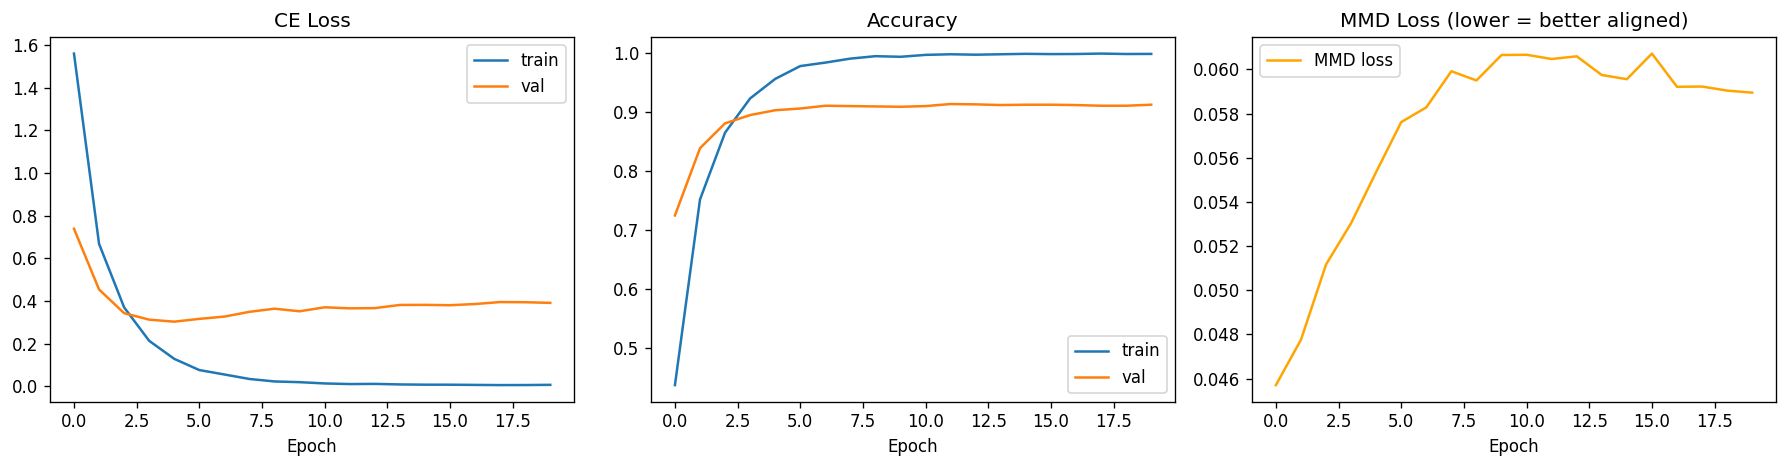

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['ce_loss'],     label='train')
axes[0].plot(history.history['val_ce_loss'], label='val')
axes[0].set_title('CE Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history.history['mmd_loss'], label='MMD loss', color='orange')
axes[2].set_title('MMD Loss (lower = better aligned)'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves_v2.png', bbox_inches='tight')
plt.show()

## 5. Source Test Evaluation

In [9]:
y_pred_src = np.argmax(model.predict(X_test, batch_size=BATCH_SIZE), axis=1)
src_f1 = f1_score(y_test, y_pred_src, average='macro')
print(f'Source Test Macro F1: {src_f1:.4f}')
print(classification_report(y_test, y_pred_src, target_names=class_names))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Source Test Macro F1: 0.8932
              precision    recall  f1-score   support

    Effector       0.94      0.97      0.95       482
   Exhausted       0.92      0.93      0.93       166
       Naive       0.83      0.84      0.84       224
   Other_CD4       0.84      0.83      0.83       321
    Th1-like       0.91      0.83      0.87       141
        Treg       0.95      0.94      0.94       372

    accuracy                           0.90      1706
   macro avg       0.90      0.89      0.89      1706
weighted avg       0.90      0.90      0.90      1706



## 6. Target Domain Evaluation (CORAL-aligned)

In [10]:
y_pred_tgt = np.argmax(model.predict(X_target_eval, batch_size=BATCH_SIZE), axis=1)
tgt_f1 = f1_score(y_target_eval, y_pred_tgt, average='macro')
print(f'Target Macro F1: {tgt_f1:.4f}')
print(classification_report(y_target_eval, y_pred_tgt, target_names=class_names))

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Target Macro F1: 0.4035
              precision    recall  f1-score   support

    Effector       0.55      0.59      0.57      2839
   Exhausted       0.07      0.09      0.08       903
       Naive       0.86      0.54      0.66      3806
   Other_CD4       0.39      0.38      0.39      2127
    Th1-like       0.19      0.19      0.19      1031
        Treg       0.44      0.67      0.53      2070

    accuracy                           0.48     12776
   macro avg       0.42      0.41      0.40     12776
weighted avg       0.54      0.48      0.50     12776



## 7. Confusion Matrices

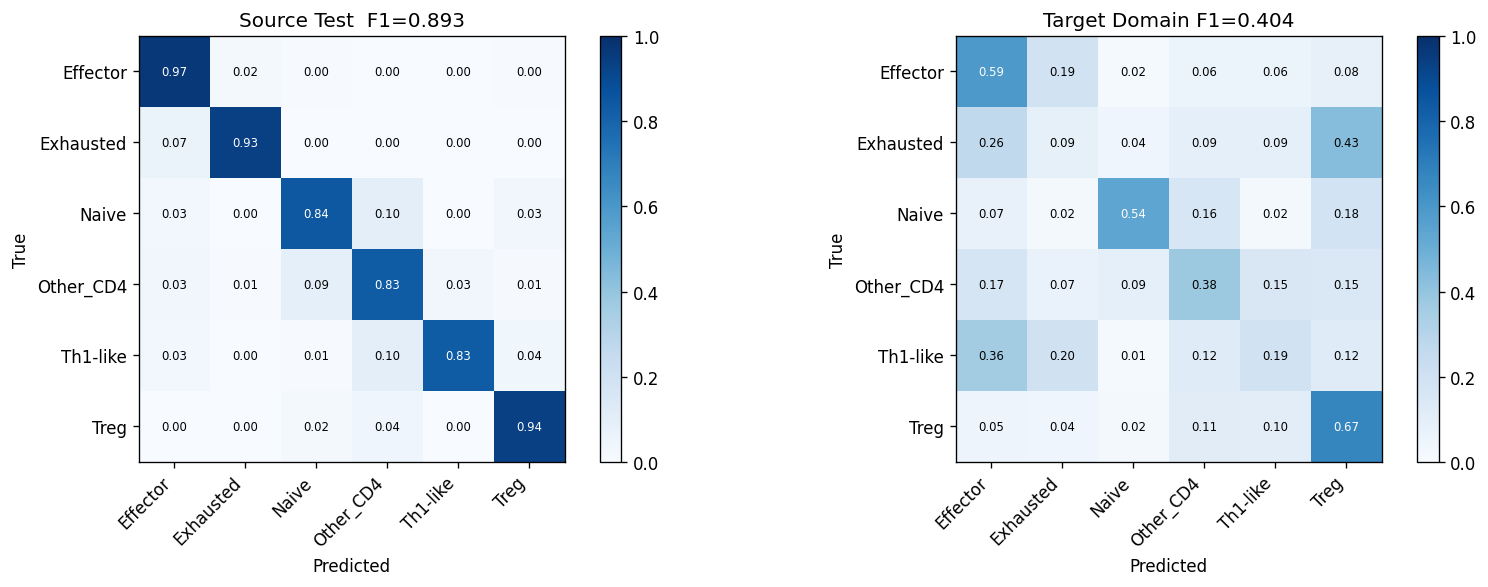

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_true, y_pred, title in [
    (axes[0], y_test,        y_pred_src, f'Source Test  F1={src_f1:.3f}'),
    (axes[1], y_target_eval, y_pred_tgt, f'Target Domain F1={tgt_f1:.3f}'),
]:
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm[i,j] > 0.5 else 'black', fontsize=7)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_v2.png', bbox_inches='tight')
plt.show()

## 8. Gene Attention Weights by Class

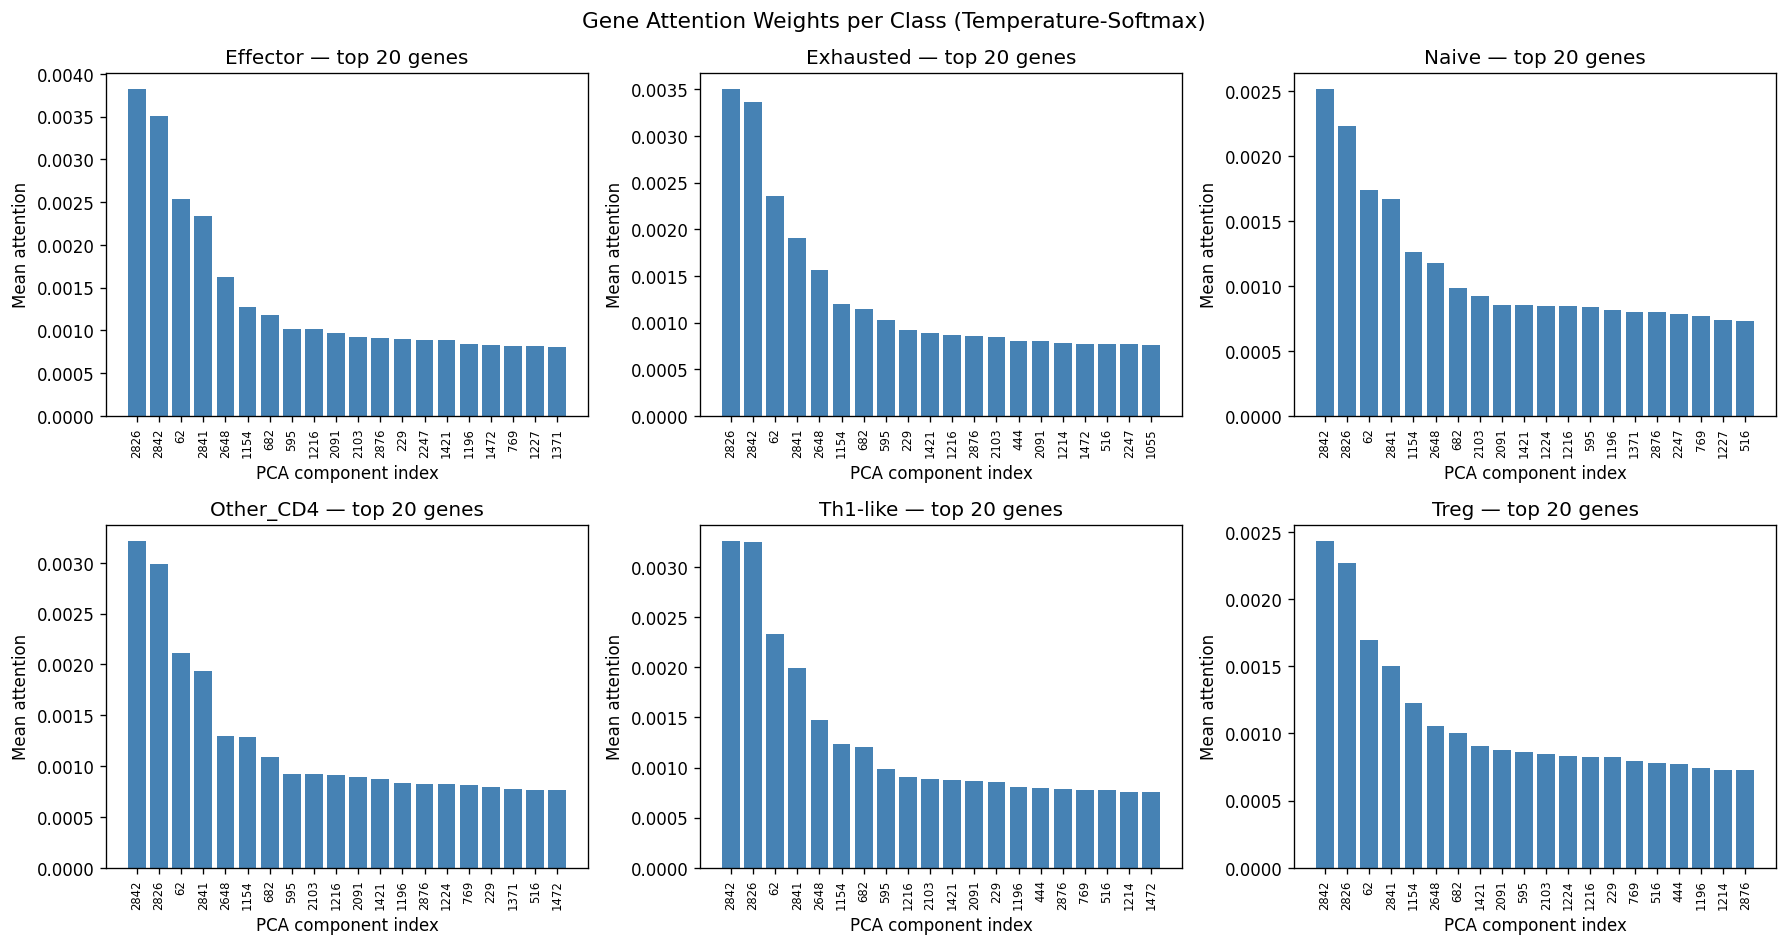

In [12]:
# Build attention-weight extractor
@tf.function
def get_attention_weights(x):
    h = model.att_hidden(x, training=False)
    logits = model.att_logits(h, training=False)
    return tf.nn.softmax(logits / model.att_temp, axis=-1)

att_weights = get_attention_weights(tf.constant(X_test)).numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
top_k = 20
for cls_idx, (cls_name, ax) in enumerate(zip(class_names, axes.flatten())):
    cls_mask  = y_test == cls_idx
    mean_att  = att_weights[cls_mask].mean(axis=0)
    top_genes = np.argsort(mean_att)[::-1][:top_k]
    ax.bar(range(top_k), mean_att[top_genes], color='steelblue')
    ax.set_title(f'{cls_name} — top {top_k} genes')
    ax.set_xlabel('PCA component index')
    ax.set_ylabel('Mean attention')
    ax.set_xticks(range(top_k))
    ax.set_xticklabels(top_genes, rotation=90, fontsize=7)
plt.suptitle('Gene Attention Weights per Class (Temperature-Softmax)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'gene_attention_by_class_v2.png', bbox_inches='tight')
plt.show()

## 9. Full Comparison Table + Save

In [13]:
src_report = classification_report(y_test,        y_pred_src, target_names=class_names, output_dict=True)
tgt_report = classification_report(y_target_eval, y_pred_tgt, target_names=class_names, output_dict=True)

results = {
    'model': 'GeneAttentionMMD',
    'config': {
        'attention_temp': ATT_TEMP,
        'mmd_weight': MMD_WEIGHT,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'epochs_trained': len(history.history['ce_loss']),
        'coral_aligned': True,
        'residual_connection': True,
        'class_weighted': False,
    },
    'source_test': {
        'macro_f1': src_f1,
        'accuracy': accuracy_score(y_test, y_pred_src),
        'per_class_f1': {cls: src_report[cls]['f1-score'] for cls in class_names},
    },
    'target_eval': {
        'macro_f1': tgt_f1,
        'accuracy': accuracy_score(y_target_eval, y_pred_tgt),
        'per_class_f1': {cls: tgt_report[cls]['f1-score'] for cls in class_names},
        'n_eval_cells': int(y_target_eval.shape[0]),
    },
}
with open(RESULTS_DIR / 'self_attention_results_v2.json', 'w') as f:
    json.dump(results, f, indent=2)

# Load v1 for comparison
v1 = json.load(open(RESULTS_DIR / 'self_attention_results.json'))

all_models = [
    ('LogReg',              0.885,                       None),
    ('MLP',                 0.884,                       None),
    ('MMD-Net',             None,                        0.194),
    ('DANN v1',             0.852,                       0.391),
    ('DANN v2',             0.875,                       0.395),
    ('GeneAtt v1 (no align)', v1['source_test']['macro_f1'], v1['target_eval']['macro_f1']),
    ('GeneAtt v2 (CORAL+MMD)', src_f1,                    tgt_f1),
]

print(f'\n{"Model":28s} {"Source F1":>10s} {"Target F1":>10s}')
print('-' * 52)
for name, sf, tf_ in all_models:
    s = f'{sf:.3f}' if sf is not None else '   —  '
    t = f'{tf_:.3f}' if tf_ is not None else '   —  '
    print(f'{name:28s} {s:>10s} {t:>10s}')


Model                         Source F1  Target F1
----------------------------------------------------
LogReg                            0.885        —  
MLP                               0.884        —  
MMD-Net                             —        0.194
DANN v1                           0.852      0.391
DANN v2                           0.875      0.395
GeneAtt v1 (no align)             0.894      0.079
GeneAtt v2 (CORAL+MMD)            0.893      0.404
